<a href="https://colab.research.google.com/github/gabrieelsky/rps-cnn/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! git clone https://github.com/gabrieelsky/rps-cnn
! mv rps-cnn/* .
! rm -r rps-cnn/ sample_data/

! mkdir -p data/raw
! curl -L -o data/raw/rockpaperscissors.zip https://www.kaggle.com/api/v1/datasets/download/drgfreeman/rockpaperscissors
! unzip -q data/raw/rockpaperscissors.zip -d data/raw/
! rm data/raw/rockpaperscissors.zip
! mkdir saved_models

In [21]:
%matplotlib inline
import importlib
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from src.data_loader import create_dataloaders, get_class_mapping
from src.models import BaselineCNN, MicroResNet, MediumCNN
from src.train import train_model, run_grid_search
from src.evaluate import evaluate_model
from src.config import *
import src.utils as utils
importlib.reload(utils)
from src.utils import (
    print_hyperparams,
    print_model_summary,
    visualize_model_architecture,
    plot_learning_curves,
    show_misclassified_grid,
 )

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = get_device()
print(f"Hardware configuration: Using device '{device}'\n")

class_mapping = get_class_mapping(RAW_DATA_DIR)
num_classes = len(class_mapping)
print(f"{num_classes} classes found: {class_mapping}\n")

Hardware configuration: Using device 'mps'

3 classes found: {'paper': 0, 'rock': 1, 'scissors': 2}



Active hyperparameters:
  Learning Rate: 0.001
  Batch Size: 32
  Optimizer: SGD
  Loss Function: CrossEntropyLoss
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 100, 150]             448
              ReLU-2         [-1, 16, 100, 150]               0
         MaxPool2d-3           [-1, 16, 50, 75]               0
            Conv2d-4           [-1, 32, 50, 75]           4,640
              ReLU-5           [-1, 32, 50, 75]               0
         MaxPool2d-6           [-1, 32, 25, 37]               0
           Flatten-7                [-1, 29600]               0
            Linear-8                   [-1, 64]       1,894,464
              ReLU-9                   [-1, 64]               0
           Linear-10                    [-1, 3]             195
Total params: 1,899,747
Trainable params: 1,899,747
Non-trainable params: 0
----------------------------------------

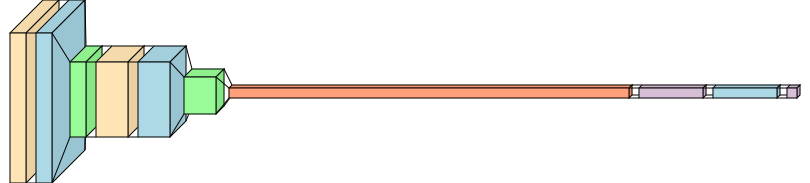

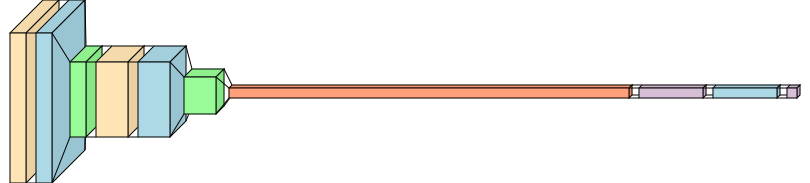

In [22]:
train_loader, val_loader, test_loader, _ = create_dataloaders(RAW_DATA_DIR, batch_size=32)

model = BaselineCNN(num_classes=num_classes, input_shape=(3, IMG_HEIGHT, IMG_WIDTH)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, weight_decay=1e-4)

print_hyperparams(1e-3, 32, optimizer.__class__.__name__, criterion.__class__.__name__)
input_size = (3, IMG_HEIGHT, IMG_WIDTH)
print_model_summary(model, input_size=input_size, device=device)
visualize_model_architecture(model, input_size=input_size)


<Figure size 640x480 with 0 Axes>

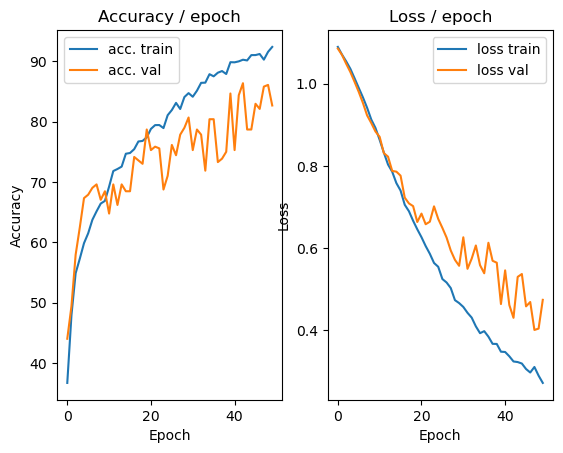

Early stopping counter: 2 out of 5

Training complete.


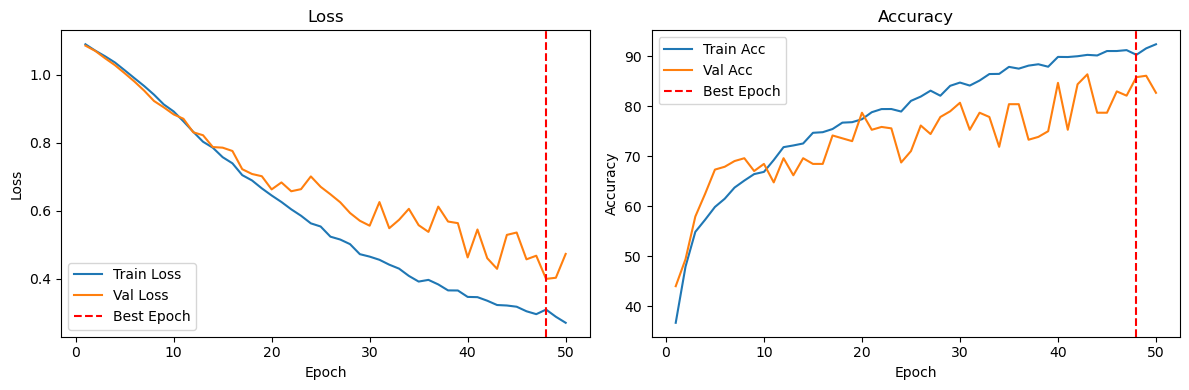


Evaluating BaselineCNN on the test set...

FINAL TEST RESULTS
Average Test Loss: 0.4122
Test Accuracy: 0.8267

Classification Report:
              precision    recall  f1-score   support

       paper       0.98      0.60      0.74       107
        rock       0.70      0.98      0.82       109
    scissors       0.90      0.89      0.90       113

    accuracy                           0.83       329
   macro avg       0.86      0.82      0.82       329
weighted avg       0.86      0.83      0.82       329



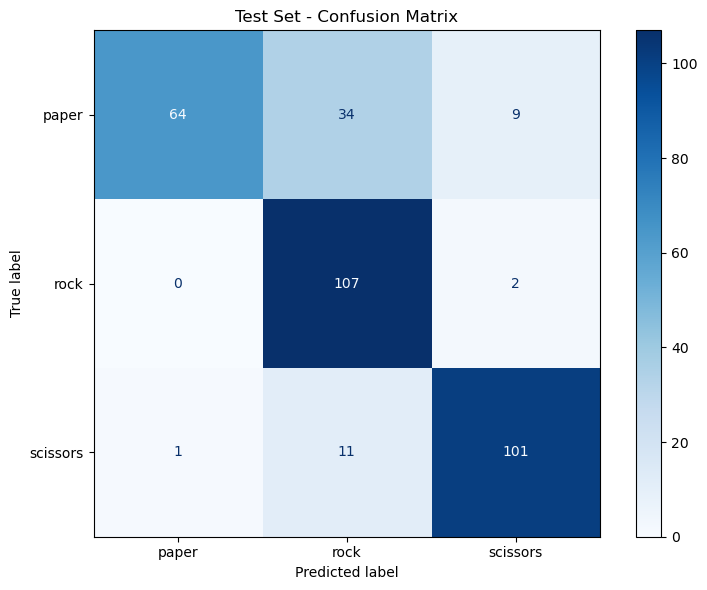

Misclassified Examples:


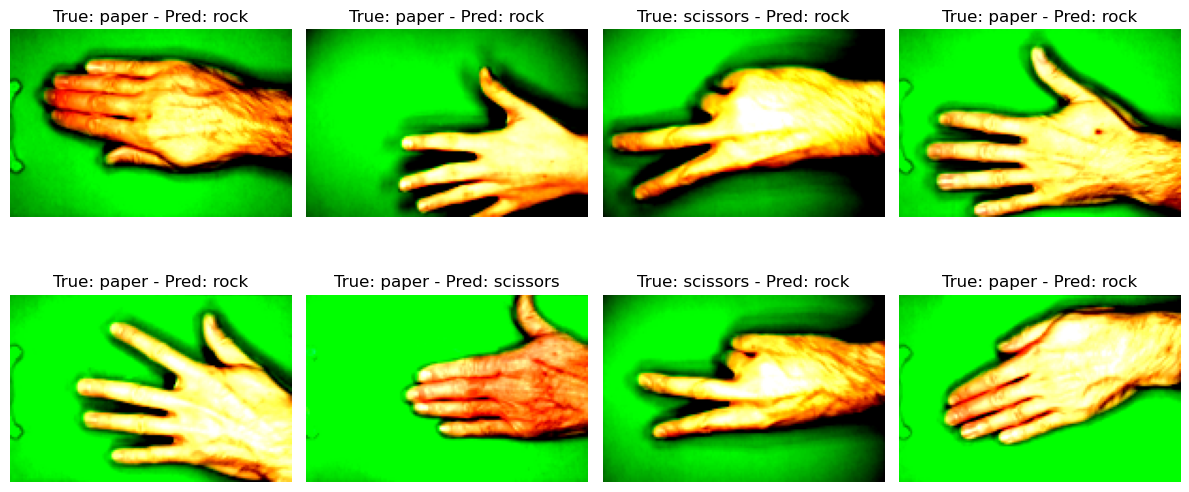


BaselineCNN weights successfully saved to /Users/gabriele/repos/rps-cnn/saved_models/baseline_cnn.pth


In [23]:
print("\nStarting BaselineCNN training with fixed defaults...")

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=50,
    patience=5,
    min_delta=1e-4
)

plot_learning_curves(history)

print("\nEvaluating BaselineCNN on the test set...")
test_loss, test_acc, all_preds, all_labels = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    class_mapping=class_mapping,
 )

class_names = [name for name, idx in sorted(class_mapping.items(), key=lambda item: item[1])]
show_misclassified_grid(test_loader.dataset, all_labels, all_preds, class_names, grid=(2, 4))

save_path = os.path.join(MODELS_DIR, "baseline_cnn.pth")
torch.save(model.state_dict(), save_path)
print(f"\nBaselineCNN weights successfully saved to {save_path}")

Active hyperparameters:
  Learning Rate: 0.0001
  Batch Size: 32
  Optimizer: SGD
  Loss Function: CrossEntropyLoss
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 100, 150]             896
       BatchNorm2d-2         [-1, 32, 100, 150]              64
              ReLU-3         [-1, 32, 100, 150]               0
         MaxPool2d-4           [-1, 32, 50, 75]               0
            Conv2d-5           [-1, 64, 50, 75]          18,496
       BatchNorm2d-6           [-1, 64, 50, 75]             128
              ReLU-7           [-1, 64, 50, 75]               0
         MaxPool2d-8           [-1, 64, 25, 37]               0
            Conv2d-9          [-1, 128, 25, 37]          73,856
      BatchNorm2d-10          [-1, 128, 25, 37]             256
             ReLU-11          [-1, 128, 25, 37]               0
        MaxPool2d-12          [-1, 128, 12, 18]    

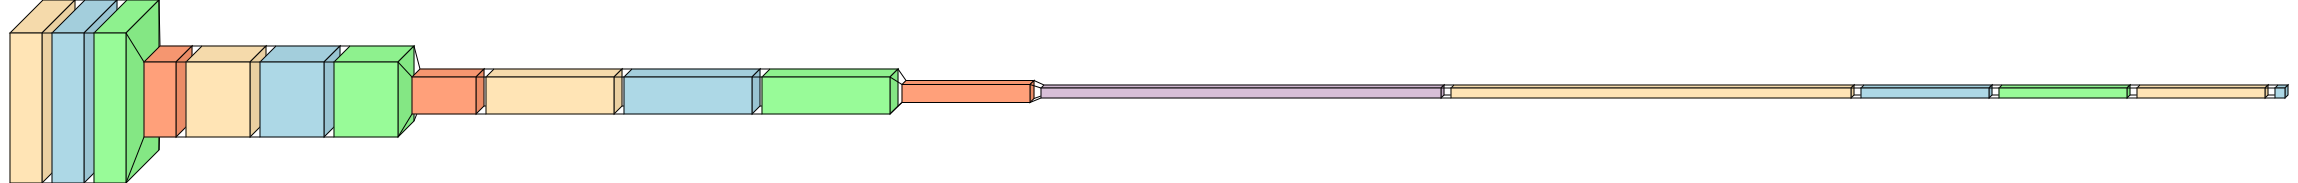

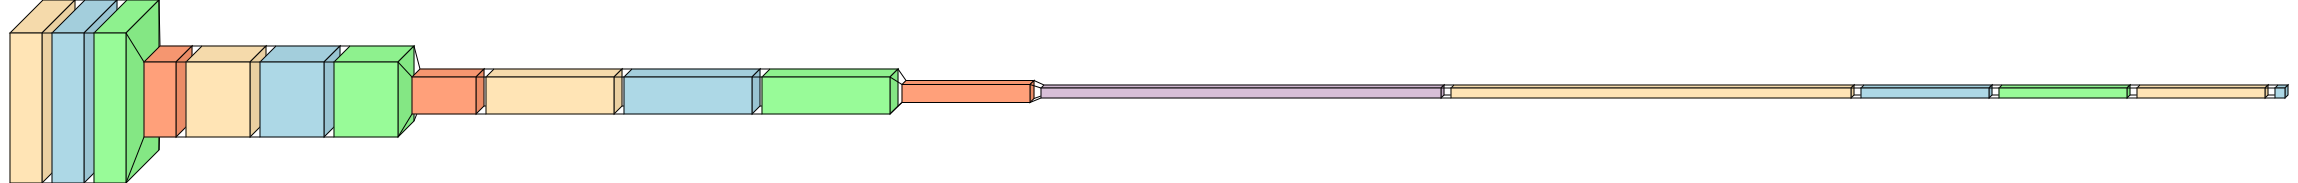

In [24]:
train_loader, val_loader, test_loader, _ = create_dataloaders(RAW_DATA_DIR, batch_size=32)

model = MediumCNN(num_classes=num_classes, input_shape=(3, IMG_HEIGHT, IMG_WIDTH), dropout_rate=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, weight_decay=1e-4)

print_hyperparams(1e-4, 32, optimizer.__class__.__name__, criterion.__class__.__name__)
input_size = (3, IMG_HEIGHT, IMG_WIDTH)
print_model_summary(model, input_size=input_size, device=device)
visualize_model_architecture(model, input_size=input_size)

<Figure size 640x480 with 0 Axes>

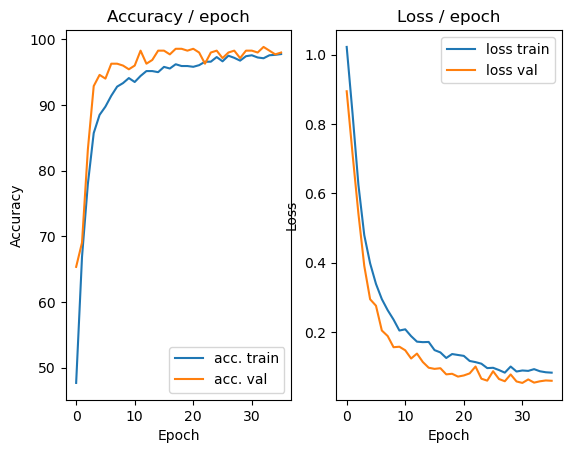

Early stopping counter: 5 out of 5
Early stopping triggered at epoch 36 (best epoch: 31).

Training complete.


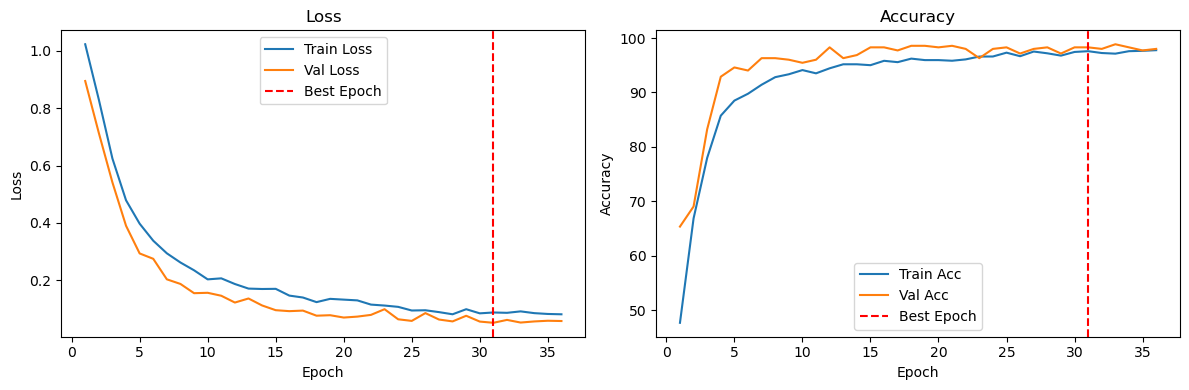


Evaluating MediumCNN on the test set...

FINAL TEST RESULTS
Average Test Loss: 0.0480
Test Accuracy: 0.9939

Classification Report:
              precision    recall  f1-score   support

       paper       1.00      0.98      0.99       107
        rock       0.99      1.00      1.00       109
    scissors       0.99      1.00      1.00       113

    accuracy                           0.99       329
   macro avg       0.99      0.99      0.99       329
weighted avg       0.99      0.99      0.99       329



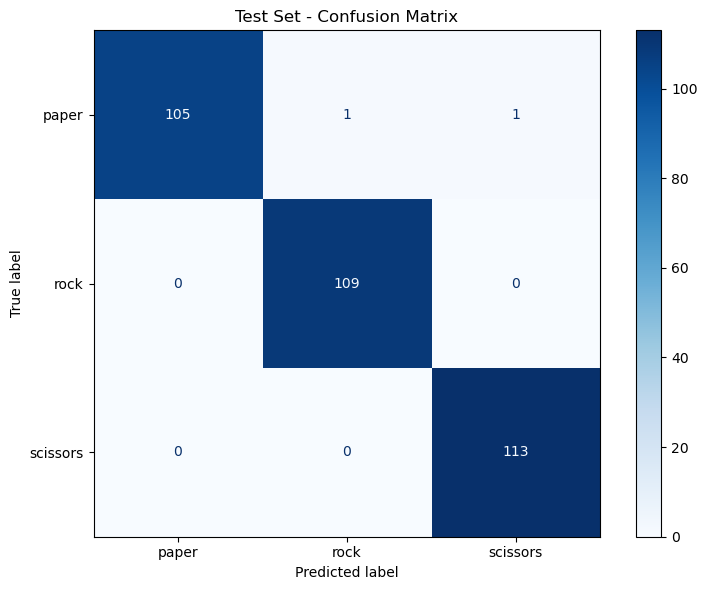

Misclassified Examples:


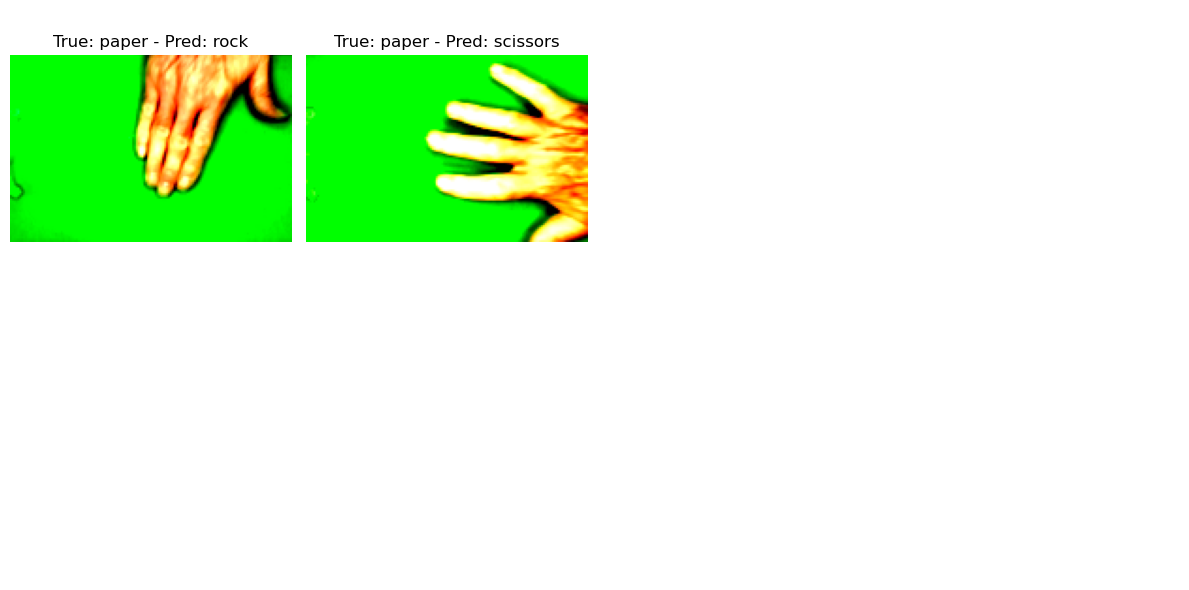


MediumCNN weights successfully saved to /Users/gabriele/repos/rps-cnn/saved_models/medium_cnn.pth


In [25]:
print("\nStarting MediumCNN training with fixed defaults...")

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=50,
    patience=5,
    min_delta=1e-4
)

plot_learning_curves(history)

print("\nEvaluating MediumCNN on the test set...")
test_loss, test_acc, all_preds, all_labels = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    class_mapping=class_mapping,
 )

class_names = [name for name, idx in sorted(class_mapping.items(), key=lambda item: item[1])]
show_misclassified_grid(test_loader.dataset, all_labels, all_preds, class_names, grid=(2, 4))

save_path = os.path.join(MODELS_DIR, "medium_cnn.pth")
torch.save(model.state_dict(), save_path)
print(f"\nMediumCNN weights successfully saved to {save_path}")

<Figure size 640x480 with 0 Axes>

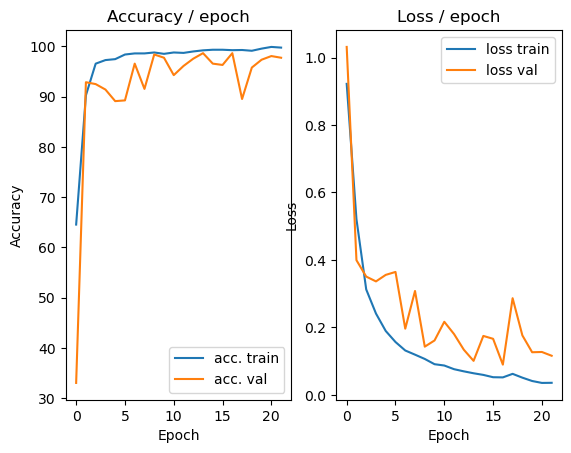

Early stopping counter: 5 out of 5
Early stopping triggered at epoch 22 (best epoch: 17).

Training complete.
    Fold 3 macro-F1: 0.9877, acc: 0.9877
Grid search complete. Top results (sorted by mean validation accuracy):
       lr  weight_decay  batch_size  mean_val_acc  std_val_acc
0  0.0010        0.0100          64      0.995886     0.001941
1  0.0001        0.0001          16      0.995886     0.004039
2  0.0010        0.0001          64      0.995885     0.003880
3  0.0001        0.0100          16      0.994060     0.004237
4  0.0010        0.0001          16      0.994057     0.006563


In [20]:
# Define hyperparameter grid for Stratified K-Fold CV using run_grid_search
param_grid = {
    'lr': [1e-3, 1e-4],
    'weight_decay': [1e-2, 1e-4],
    'batch_size': [16, 64]
}

print('Initiating Stratified K-Fold Grid Search (this may take a while)...')
tuning_results = run_grid_search(
    MicroResNet,
    param_grid,
    None,
    RAW_DATA_DIR,
    device=device,
    num_classes=num_classes,
    n_splits=3,
    seed=RANDOM_SEED,
    patience=5,
    min_delta=1e-4,
    max_epochs=50
 )
tuning_results.to_csv('saved_models/grid_search_results.csv', index=False)
print('Grid search complete. Top results (sorted by mean validation accuracy):')
print(tuning_results[['lr', 'weight_decay', 'batch_size', 'mean_val_acc', 'std_val_acc']].head())

In [10]:
# Extract best configuration from tuning results
# best_config = tuning_results.iloc[0]
best_config = {
    'lr': 0.001,
    'batch_size': 64,
    'weight_decay': 0.01
}

best_lr = float(best_config['lr'])
best_batch_size = int(best_config['batch_size'])
best_weight_decay = float(best_config.get('weight_decay', 0.0))

print(f"Selected best MicroResNet config: lr={best_lr}, batch_size={best_batch_size}, weight_decay={best_weight_decay}")

Selected best MicroResNet config: lr=0.001, batch_size=64, weight_decay=0.01


Active hyperparameters:
  Learning Rate: 0.001
  Batch Size: 64
  Optimizer: AdamW
  Loss Function: CrossEntropyLoss
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 50, 75]           4,704
       BatchNorm2d-2           [-1, 32, 50, 75]              64
         MaxPool2d-3           [-1, 32, 25, 38]               0
            Conv2d-4           [-1, 32, 25, 38]           9,216
       BatchNorm2d-5           [-1, 32, 25, 38]              64
            Conv2d-6           [-1, 32, 25, 38]           9,216
       BatchNorm2d-7           [-1, 32, 25, 38]              64
     ResidualBlock-8           [-1, 32, 25, 38]               0
            Conv2d-9           [-1, 64, 13, 19]          18,432
      BatchNorm2d-10           [-1, 64, 13, 19]             128
           Conv2d-11           [-1, 64, 13, 19]          36,864
      BatchNorm2d-12           [-1, 64, 13, 19]   

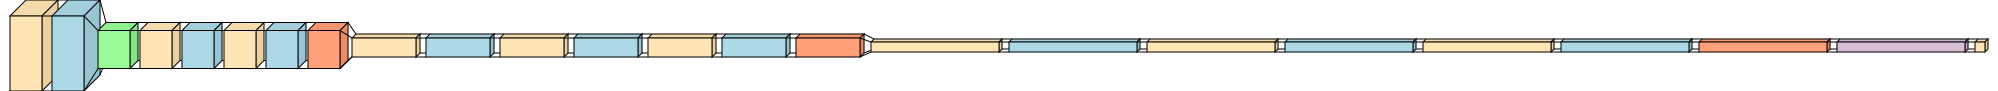

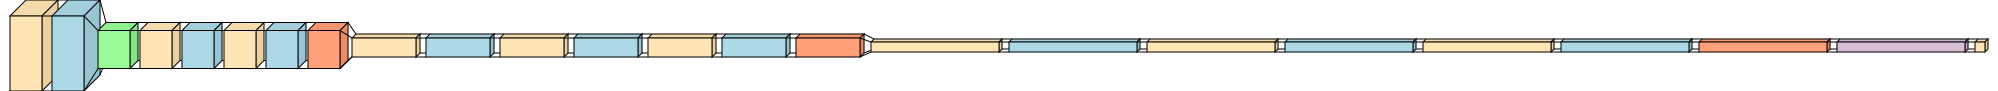

In [12]:
best_weight_decay = 0
train_loader, val_loader, test_loader, _ = create_dataloaders(RAW_DATA_DIR, batch_size=best_batch_size)


model = MicroResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=best_weight_decay)

print_hyperparams(best_lr, best_batch_size, optimizer.__class__.__name__, criterion.__class__.__name__)
input_size = (3, IMG_HEIGHT, IMG_WIDTH)
print_model_summary(model, input_size=input_size, device=device)
visualize_model_architecture(model, input_size=input_size)

<Figure size 640x480 with 0 Axes>

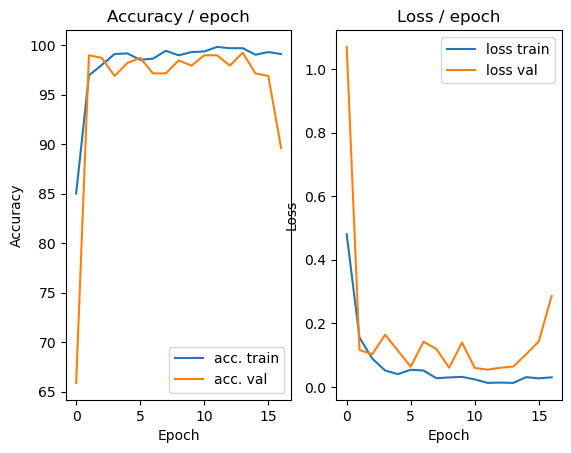

Early stopping counter: 5 out of 5
Early stopping triggered at epoch 17 (best epoch: 12).

Training complete.


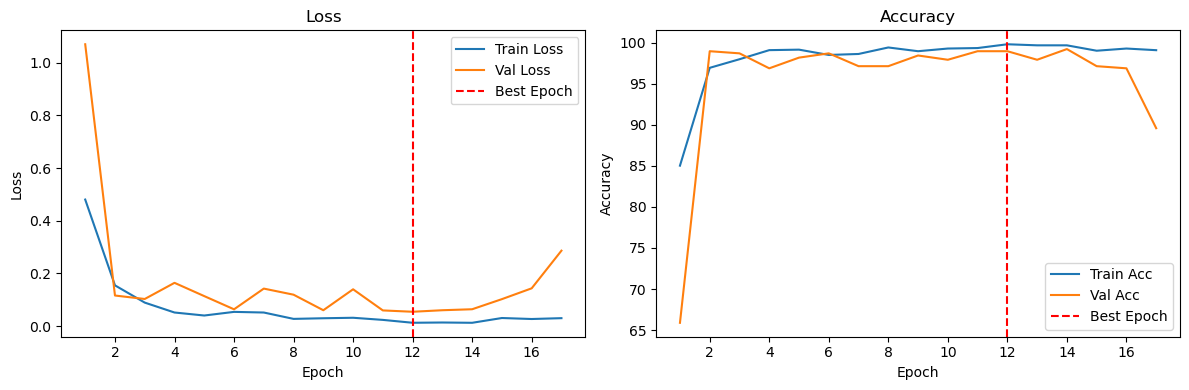


Evaluating MicroResNet on the test set...

FINAL TEST RESULTS
Average Test Loss: 0.0515
Test Accuracy: 0.9909

Classification Report:
              precision    recall  f1-score   support

       paper       0.99      0.99      0.99       107
        rock       0.98      1.00      0.99       109
    scissors       1.00      0.98      0.99       113

    accuracy                           0.99       329
   macro avg       0.99      0.99      0.99       329
weighted avg       0.99      0.99      0.99       329



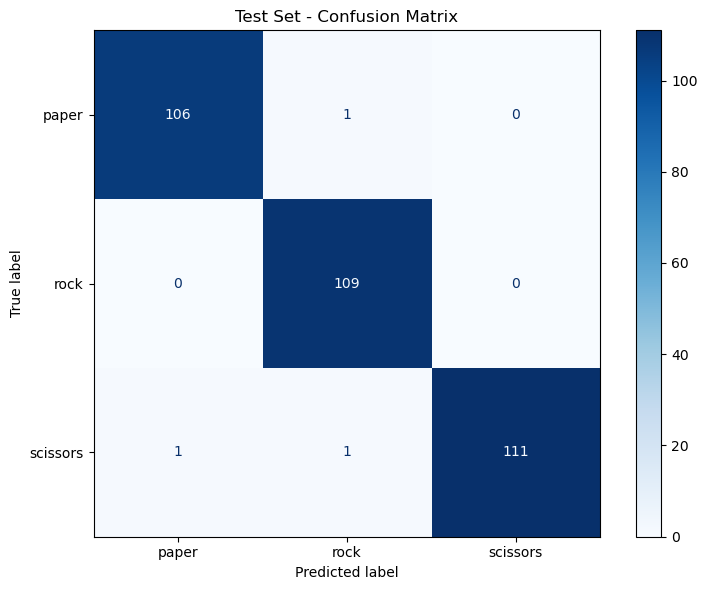

Misclassified Examples:


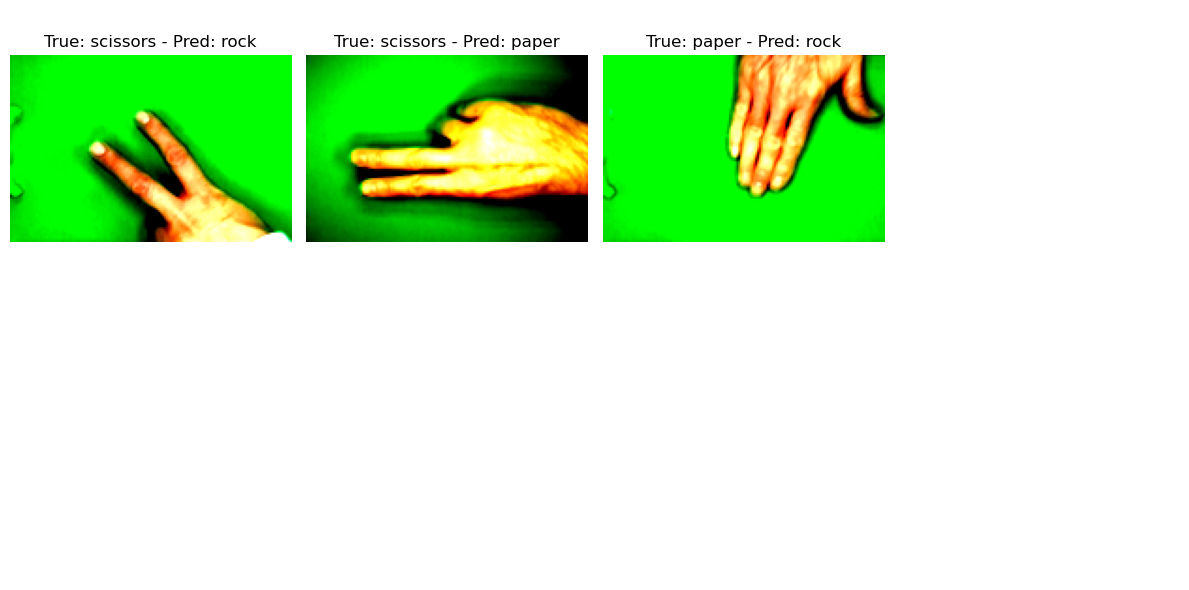


MicroResNet weights successfully saved to /Users/gabriele/repos/rps-cnn/saved_models/micro_resnet.pth


In [13]:
print("\nStarting MicroResNet training with the best parameters...")

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=TRAINING_EPOCHS,
    patience=5,
    min_delta=1e-4
)

plot_learning_curves(history)

print("\nEvaluating MicroResNet on the test set...")
test_loss, test_acc, all_preds, all_labels = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    class_mapping=class_mapping,
 )

class_names = [name for name, idx in sorted(class_mapping.items(), key=lambda item: item[1])]
show_misclassified_grid(test_loader.dataset, all_labels, all_preds, class_names, grid=(2, 4))

save_path = os.path.join(MODELS_DIR, "micro_resnet.pth")
torch.save(model.state_dict(), save_path)
print(f"\nMicroResNet weights successfully saved to {save_path}")

In [ ]:
! cd data/custom_test/
! curl -L -o rockpaperscissors.zip https://www.kaggle.com/api/v1/datasets/download/glushko/rock-paper-scissors-dataset
! unzip -q rockpaperscissors.zip -d .
! rm rockpaperscissors.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  351M  100  351M    0     0  22.4M      0  0:00:15  0:00:15 --:--:-- 25.1M


: 

In [27]:
from src.models import MicroResNet
from src.webcam_utils import run_webcam_generalization_test

model = MicroResNet(num_classes=num_classes).to(device)
state_dict = torch.load(os.path.join(MODELS_DIR, "micro_resnet.pth"), map_location=device)
model.load_state_dict(state_dict)

# The function saves the captured images and a CSV summary under logs/webcam_generalization/.
webcam_results = run_webcam_generalization_test(
    model=model,
    device=device,
    class_mapping=class_mapping,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    samples_per_class=5,
    camera_index=0,
    save_dir=os.path.join(BASE_DIR, "logs", "webcam_generalization"),
)

webcam_results.head()


Webcam test started.
Press r/p/s to capture the current frame as rock/paper/scissors.
Press q or Esc to finish early.


KeyboardInterrupt: 